# ДЗ-2 по Теории и практике онлайн экспериментов


Данные лежат на диске: https://disk.yandex.ru/d/9EcCqk-1CUyiCA

### Задание 1 (4 балла)

Представим, что у нас есть сервис для продажи некоторых товаров (например, мыла). Мы выкатываем новые фичи и проводим тесты, а затем сохраняем логи каждого теста в следующем формате:

- `user_id` - уникальный id посетителя сайта
- `dt` - дата события
- `event` - название события
- `group` - группа, в которую попал пользователь (распределение может происходить на разных этапах воронки для разных тестов - например, при первом посещении или при первом добавлении в корзину)
- `visit_id` - уникальный id визита
- `cart_id` - уникальный id корзины
- amount - текущая сумма корзины
- `num_items` - текущее количество товаров в корзине


1. Обратимся к метрике **average revenue per paying user**. Вам даны две очень похожие группы (файл `aa_test_logs.pkl`). 

- Постройте распределение p-value для теста на равенство средних между группами.
- Найдите, на каком уровне искусственно добавленного эффекта средняя выручка в группах станет различима. Ошибку первого рода считайте заданной и равной 0.05, ошибку 2-го рода равной 0.2.

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
from scipy.stats import mannwhitneyu

In [96]:
df1 = pd.read_pickle('hw-3/aa_test_logs.pkl')

In [112]:
df1

,user_id,dt,event,group,visit_id,cart_id,amount,num_items
0,user_0,2025-03-06 00:00:00,cart-add,test,visit_1,cart_0,43.22,1.0
1,user_0,2025-03-06 00:01:00,cart-add,test,visit_1,cart_0,97.84,2.0
2,user_0,2025-03-06 00:02:00,cart-add,test,visit_1,cart_0,146.27,7.0
3,user_0,2025-03-06 00:10:00,cart-paid,test,visit_1,cart_0,NaN,NaN
4,user_1,2025-03-11 00:00:00,cart-add,control,visit_2,cart_1,26.08,3.0
...,...,...,...,...,...,...,...,...
31520,user_998,2025-03-03 00:13:00,cart-paid,control,visit_1482,cart_1455,NaN,NaN
31521,user_999,2025-03-19 00:00:00,cart-add,test,visit_1483,cart_1456,20.60,4.0
31522,user_999,2025-03-19 00:04:00,cart-add,test,visit_1483,cart_1456,44.49,12.0
31523,user_999,2025-03-19 00:06:00,cart-add,test,visit_1483,cart_1456,54.66,16.0


In [12]:
def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    for name, pvalues in dict_pvalues.items():
        Y = [np.mean(pvalues < x) for x in X]
        plt.plot(X, Y, label=name)

    plt.plot([0, 1], [0, 1], "--k", alpha=0.8)
    plt.title("Оценка распределения p-value", size=16)
    plt.xlabel("p-value", size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

In [142]:
df1_test = df1[df1['group'] == 'test']
tmp_df = df1_test.groupby('cart_id')['event'].agg(lambda s: np.sum(s == 'cart-paid'))
paid_cart = set(np.array(tmp_df[tmp_df != 0].index))
paid_df = df1_test[df1_test['cart_id'].apply(lambda s: s in paid_cart )]
rpu_test = paid_df.groupby('cart_id').max().groupby('user_id')['amount'].sum()

mp_df = df1_test.groupby('cart_id')['event'].agg(lambda s: np.sum(s == 'cart-paid'))
paid_cart = set(np.array(tmp_df[tmp_df != 0].index))
paid_df = df1_test[df1_test['cart_id'].apply(lambda s: s in paid_cart )]
df_sm_test = paid_df.groupby('cart_id').max().groupby('user_id')['amount'].sum()
df_len_test = paid_df.groupby('cart_id').max().groupby('user_id')['amount'].count()

In [143]:
df1_control = df1[df1['group'] == 'control']
tmp_df = df1_control.groupby('cart_id')['event'].agg(lambda s: np.sum(s == 'cart-paid'))
paid_cart = set(np.array(tmp_df[tmp_df != 0].index))
paid_df = df1_control[df1_control['cart_id'].apply(lambda s: s in paid_cart )]
rpu_control = paid_df.groupby('cart_id').max().groupby('user_id')['amount'].sum()

mp_df = df1_control.groupby('cart_id')['event'].agg(lambda s: np.sum(s == 'cart-paid'))
paid_cart = set(np.array(tmp_df[tmp_df != 0].index))
paid_df = df1_control[df1_control['cart_id'].apply(lambda s: s in paid_cart )]
df_sm_control = paid_df.groupby('cart_id').max().groupby('user_id')['amount'].sum()
df_len_control = paid_df.groupby('cart_id').max().groupby('user_id')['amount'].count()

In [118]:
def bootstrap_sample(data, n_iterations=1000, statistic_func=np.mean):
    bootstrap_stats = []
    n = len(data)
    for _ in range(n_iterations):
        sample = np.random.choice(data, size=n, replace=True)
        stat = statistic_func(sample)
        bootstrap_stats.append(stat)
    return np.array(bootstrap_stats)

In [145]:
alpha = 0.05
pvalues = []
n_iterations = 1000
for _ in range(n_iterations):
    indexes_test = np.random.choice(np.arange(len(rpu_test)), len(rpu_test), True)
    indexes_control = np.random.choice(np.arange(len(rpu_control)), len(rpu_control), True)
    pvalues.append(stats.ttest_ind(rpu_test[indexes_test], rpu_control[indexes_control]).pvalue)

errors = np.mean(np.array(pvalues) < alpha)
print(f'доля ошибок 1 рода: {errors}')

/var/folders/cs/fdh1dn_j3g9ccz7ksycbqb140000gn/T/ipykernel_8295/3764554618.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pvalues.append(stats.ttest_ind(rpu_test[indexes_test], rpu_control[indexes_control]).pvalue)


доля ошибок 1 рода: 0.055


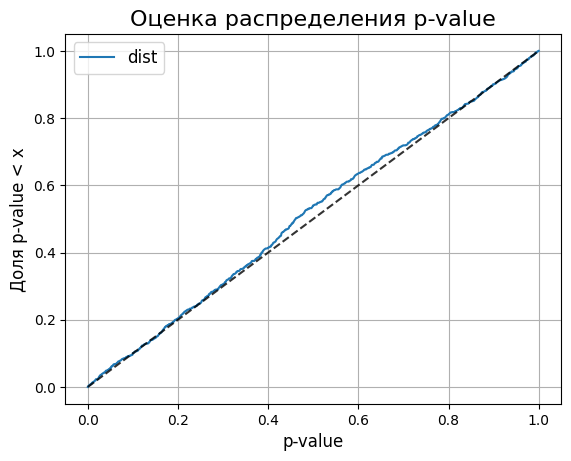

In [146]:
plot_pvalue_distribution({'dist': pvalues})

In [157]:
alpha = 0.05
pvalues = []
n_iterations = 1000
effect = 10
for _ in range(n_iterations):
    indexes_test = np.random.choice(np.arange(len(rpu_test)), len(rpu_test), True)
    indexes_control = np.random.choice(np.arange(len(rpu_control)), len(rpu_control), True)
    pvalues.append(stats.ttest_ind(rpu_test[indexes_test] + np.random.normal(effect), rpu_control[indexes_control]).pvalue)

errors = np.mean(np.array(pvalues) < alpha)
print(f'доля ошибок 1 рода: {errors}')

/var/folders/cs/fdh1dn_j3g9ccz7ksycbqb140000gn/T/ipykernel_8295/1144210973.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pvalues.append(stats.ttest_ind(rpu_test[indexes_test] + np.random.normal(effect), rpu_control[indexes_control]).pvalue)


доля ошибок 1 рода: 0.591


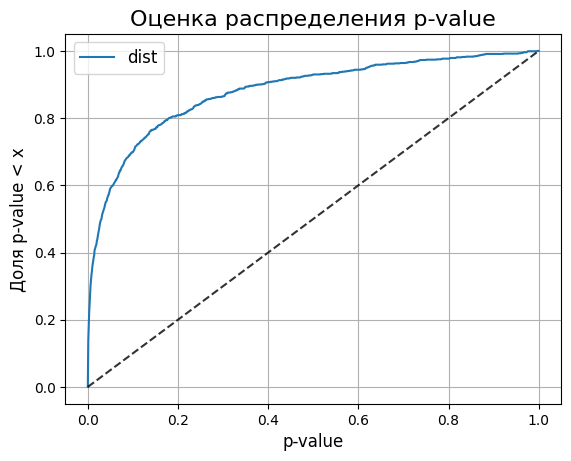

In [158]:
plot_pvalue_distribution({'dist': pvalues})

In [154]:
from tqdm import tqdm

alpha = 0.05
target_power = 0.8   # требуемая мощность (1 - β, где β=0.2)
n_experiments = 1000
n_iterations = 500

for effect in tqdm(range(0, 1000, 5)):
    rejection_count = 0
    for _ in range(n_experiments):
        st = []
        # В каждом эксперименте формируем бутстрап-выборку
        for _ in range(n_iterations):
            indexes_test = np.random.choice(np.arange(len(rpu_test)), len(rpu_test), replace=True)
            indexes_control = np.random.choice(np.arange(len(rpu_control)), len(rpu_control), replace=True)
            diff = (rpu_test[indexes_test] + np.random.normal(loc=effect)) \
                   .mean() - rpu_control[indexes_control].mean()
            st.append(diff)
        left, right = np.quantile(st, [alpha / 2, 1 - alpha / 2])
        if left > 0:
            rejection_count += 1

    power = rejection_count / n_experiments
    if power >= target_power:
        print("Detected difference on effect", effect, "with power", power)
        break


  0%|          | 0/200 [00:00<?, ?it/s]

/var/folders/cs/fdh1dn_j3g9ccz7ksycbqb140000gn/T/ipykernel_8295/62853384.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  diff = (rpu_test[indexes_test] + np.random.normal(loc=effect)) \
/var/folders/cs/fdh1dn_j3g9ccz7ksycbqb140000gn/T/ipykernel_8295/62853384.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .mean() - rpu_control[indexes_control].mean()
  1%|          | 2/200 [03:21<5:32:44, 100.83s/it]

Detected difference on effect 10 with power 0.932


2. На данных `aa_test_logs.pkl` сравните мощность линеаризации, бутстрапа, бакетизации и дельта-метода для метрики **среднего чека**. Какой метод получился наиболее мощным? Как вы думаете, почему?

In [180]:
df1['prev_amount'] = df1.groupby('cart_id')['amount'].shift(1)
df_paid = df1[df1['event'] == 'cart-paid'].copy()

control_agg = df_paid[df_paid['group'] == 'control'].groupby('user_id')['prev_amount'].sum()
test_agg    = df_paid[df_paid['group'] == 'test'].groupby('user_id')['prev_amount'].sum()

rpu_control = control_agg.values
rpu_test    = test_agg.values

print("Количество пользователей в control:", len(rpu_control))
print("Количество пользователей в test:", len(rpu_test))

def bootstrap_diff(a, b, n_iterations=500):
    st = []
    for _ in range(n_iterations):
        idx_a = np.random.choice(len(a), len(a), replace=True)
        idx_b = np.random.choice(len(b), len(b), replace=True)
        st.append(a[idx_a].mean() - b[idx_b].mean())
    return np.array(st)

def get_bootstrap_pvalue(a, b, n_iterations=500):
    diffs = bootstrap_diff(a, b, n_iterations)
    obs_diff = a.mean() - b.mean()
    diff_std = diffs.std(ddof=1)
    if diff_std == 0:
        return 1.0
    z = abs(obs_diff) / diff_std
    pval = 2 * (1 - stats.norm.cdf(z))
    return pval

def bucket_test(a, b, n_buckets=50):
    df_a = pd.DataFrame({'value': a})
    df_a['group'] = 'A'
    df_b = pd.DataFrame({'value': b})
    df_b['group'] = 'B'
    df_all = pd.concat([df_a, df_b], ignore_index=True)
    
    df_all['bucket'] = np.random.randint(0, n_buckets, size=len(df_all))
    
    bucket_agg = df_all.groupby(['group','bucket'])['value'].mean().reset_index()
    pivoted = bucket_agg.pivot(index='bucket', columns='group', values='value').dropna()

    _, pval = stats.ttest_ind(pivoted['A'], pivoted['B'], equal_var=False)
    return pval

def bucketize_test(control, test, n_buckets=10):
    control_buckets = np.array_split(np.sort(control), n_buckets)
    test_buckets = np.array_split(np.sort(test), n_buckets)
    p_value = stats.ttest_ind([np.mean(bucket) for bucket in control_buckets],
                              [np.mean(bucket) for bucket in test_buckets],
                              equal_var=False).pvalue
    return p_value

def delta_test(a, b):
    mean_control = np.mean(a)
    mean_test = np.mean(b)
    var_control = np.var(a, ddof=1)
    var_test = np.var(b, ddof=1)
    n_control = len(a)
    n_test = len(b)
    se = np.sqrt(var_control / n_control + var_test / n_test)
    t_stat = (mean_test - mean_control) / se
    df = (var_control/n_control + var_test/n_test)**2 / ((var_control/n_control)**2 / (n_control - 1) + (var_test/n_test)**2 / (n_test - 1))
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=df))
    return p_value

def linearization_test(a, b):
    _, pval = stats.ttest_ind(a, b, equal_var=False)
    return pval

alpha = 0.05
n_experiments = 300
n_boot_iterations = 300
effect_sizes = np.linspace(0, 20, 11)

bootstrap_power    = []
bucket_power       = []
delta_power        = []
lin_power          = []

for eff in tqdm(effect_sizes, desc="Effect Size"):
    bs_rejections   = 0
    buck_rejections = 0
    delta_rejections= 0
    lin_rejections  = 0

    for _ in range(n_experiments):
        idx_c = np.random.choice(len(rpu_control), len(rpu_control), replace=True)
        idx_t = np.random.choice(len(rpu_test), len(rpu_test), replace=True)
        
        control_sample = rpu_control[idx_c]
        test_sample = rpu_test[idx_t] + eff
        
        p_boot = get_bootstrap_pvalue(control_sample, test_sample, n_iterations=n_boot_iterations)
        if p_boot < alpha:
            bs_rejections += 1
        
        p_buck = bucket_test(control_sample, test_sample, n_buckets=50)
        if p_buck < alpha:
            buck_rejections += 1

        p_delta = delta_test(control_sample, test_sample)
        if p_delta < alpha:
            delta_rejections += 1
        
        p_lin = linearization_test(control_sample, test_sample)
        if p_lin < alpha:
            lin_rejections += 1

    bootstrap_power.append(bs_rejections / n_experiments)
    bucket_power.append(buck_rejections / n_experiments)
    delta_power.append(delta_rejections / n_experiments)
    lin_power.append(lin_rejections / n_experiments)

Количество пользователей в control: 1939
Количество пользователей в test: 1936


Effect Size:   0%|          | 0/11 [00:00<?, ?it/s]

Effect Size: 100%|██████████| 11/11 [00:37<00:00,  3.39s/it]


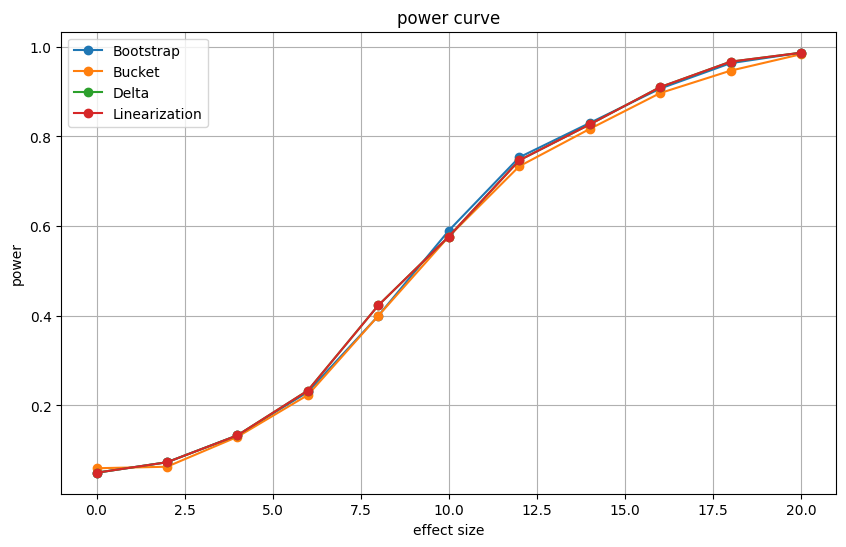

In [181]:
plt.figure(figsize=(10, 6))
plt.plot(effect_sizes, bootstrap_power, label='Bootstrap', marker='o')
plt.plot(effect_sizes, bucket_power,    label='Bucket',    marker='o')
plt.plot(effect_sizes, delta_power,     label='Delta',     marker='o')
plt.plot(effect_sizes, lin_power,       label='Linearization', marker='o')

plt.title("power curve")
plt.xlabel("effect size")
plt.ylabel("power")
plt.legend()
plt.grid(True)
plt.show()

Наиболее мощной выглядит линеаризация. Я думаю, что это из-за того что она проще - она сводит ratio-метрику к линейному показателю, что позволяет эффективно снизить дисперсию и сделать различия между группами более заметными.

3. Мы сделали рекомендательную систему, которая после добавления товара в корзину предлагает добавить похожие или комплементарные. Логи проведенного теста сохранены в файле `ab_test_logs.pkl`. 

- Проверьте гипотезу о том, что это изменение значимо повлияло на ARPPU наших power users (95%-й процентиль).
- Проверьте гипотезу о том, что это изменение значимо повлияло на ARPPU всех юзеров.

In [184]:
df13 = pd.read_pickle('hw-3/ab_test_logs.pkl')
df13

,user_id,dt,event,group,visit_id,cart_id,amount,num_items,old_amount
0,user_0,2025-03-06 00:00:00,cart-add,test,visit_1,cart_0,43.22,1.0,43.22
1,user_0,2025-03-06 00:01:00,cart-add,test,visit_1,cart_0,97.84,2.0,97.84
2,user_0,2025-03-06 00:02:00,cart-add,test,visit_1,cart_0,146.27,7.0,146.27
3,user_0,2025-03-06 00:10:00,cart-paid,test,visit_1,cart_0,NaN,NaN,NaN
4,user_1,2025-03-11 00:00:00,cart-add,control,visit_2,cart_1,26.08,3.0,26.08
...,...,...,...,...,...,...,...,...,...
31520,user_998,2025-03-03 00:13:00,cart-paid,control,visit_1482,cart_1455,NaN,NaN,NaN
31521,user_999,2025-03-19 00:00:00,cart-add,test,visit_1483,cart_1456,20.60,4.0,20.60
31522,user_999,2025-03-19 00:04:00,cart-add,test,visit_1483,cart_1456,44.49,12.0,44.49
31523,user_999,2025-03-19 00:06:00,cart-add,test,visit_1483,cart_1456,54.66,16.0,54.66


In [194]:
is_paid = df13.groupby('cart_id')['event'].apply(lambda x: 'cart-paid' in x.values)
data_ispaid = pd.merge(df13, is_paid.rename('is_paid'), on='cart_id')
receipts = data_ispaid.loc[data_ispaid.groupby('cart_id')['old_amount'].idxmax()].copy()

receipts['final_amount'] = receipts['old_amount'] * receipts['is_paid']
users_revenue = receipts.groupby('user_id').agg({'final_amount': 'sum', 'group': 'last'})
users_revenue.rename(columns={'final_amount': 'amount'}, inplace=True)

users_revenue.head()

,amount,group
user_id,,
user_0,146.27,test
user_1,103.95,control
user_10,238.89,test
user_100,146.09,test
user_1000,53.21,test


In [195]:
def get_percentile_ci(bootstrap_stats, alpha):
    left, right = np.quantile(bootstrap_stats, [alpha / 2, 1 - alpha / 2])
    return left, right

def get_mean_ci(control, test, alpha=0.05, n_bootstrap=10000):
    obs_diff = test.mean() - control.mean()
    n_c = len(control)
    n_t = len(test)
    
    bs_control = np.random.choice(control, (n_bootstrap, n_c), replace=True)
    bs_test = np.random.choice(test, (n_bootstrap, n_t), replace=True)
    bs_diff = bs_test.mean(axis=1) - bs_control.mean(axis=1)
    ci = get_percentile_ci(bs_diff, alpha)
    effect_flag = not (ci[0] < 0 < ci[1])
    return obs_diff, ci, effect_flag

In [197]:
alpha = 0.05
control_revenue = users_revenue.loc[users_revenue.group == 'control', 'amount'].values
test_revenue    = users_revenue.loc[users_revenue.group == 'test', 'amount'].values

q_control_95 = np.quantile(control_revenue, 0.95)
q_test_95 = np.quantile(test_revenue, 0.95)
obs_diff_95 = q_test_95 - q_control_95
obs_diff_95_rel = (q_test_95 / q_control_95 - 1) * 100

n_bootstrap = 10000
bs_control = np.random.choice(control_revenue, (n_bootstrap, len(control_revenue)), replace=True)
bs_test = np.random.choice(test_revenue, (n_bootstrap, len(test_revenue)), replace=True)
bs_q_control = np.quantile(bs_control, 0.95, axis=1)
bs_q_test = np.quantile(bs_test, 0.95, axis=1)
bs_diff_95 = bs_q_test - bs_q_control
ci_95 = get_percentile_ci(bs_diff_95, alpha)
effect_flag_95 = not (ci_95[0] < 0 < ci_95[1])

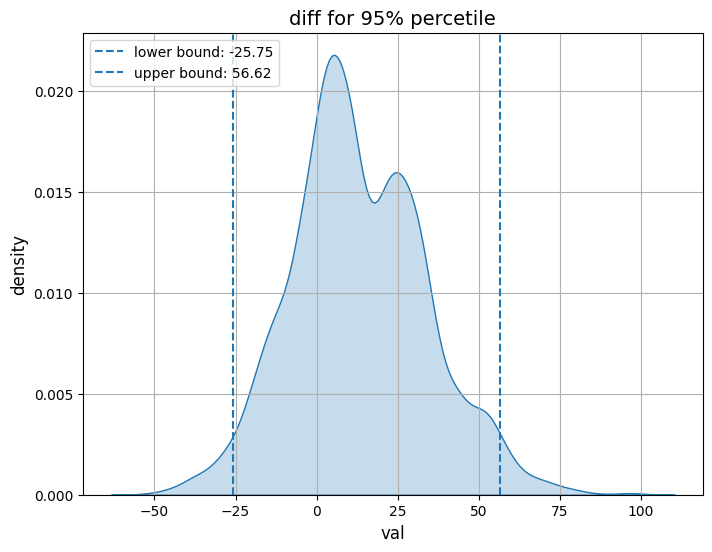

In [201]:
plt.figure(figsize=(8, 6))
sns.kdeplot(bs_diff_95, fill=True, bw_method='scott')
plt.axvline(ci_95[0], linestyle='--', 
            label=f"lower bound: {ci_95[0]:.2f}")
plt.axvline(ci_95[1], linestyle='--', 
            label=f"upper bound: {ci_95[1]:.2f}")
plt.title(f"diff for 95% percetile", fontsize=14)
plt.xlabel("val", fontsize=12)
plt.ylabel("density", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [205]:
print("Power Users (95%-й процентиль)")
print(f"95%-й процентиль (control): {q_control_95:0.2f}")
print(f"95%-й процентиль (test):    {q_test_95:0.2f}")
print(f"Абсолютная разница:         {obs_diff_95:0.2f}")
print(f"Относительная разница:      {obs_diff_95_rel:0.2f}%")
print(f"95% доверительный интервал разности: ({ci_95[0]:0.2f}, {ci_95[1]:0.2f})")
print("Статистически значимый эффект (power users)?", effect_flag_95)

Power Users (95%-й процентиль)
95%-й процентиль (control): 401.86
95%-й процентиль (test):    409.31
Абсолютная разница:         7.45
Относительная разница:      1.85%
95% доверительный интервал разности: (-25.75, 56.62)
Статистически значимый эффект (power users)? False


Так как интервал включает 0, мы не можем отвергнуть нулевую гипотезу о том, что изменений нет

In [198]:
bs_control = np.random.choice(control_revenue, (n_bootstrap, len(control_revenue)), replace=True)
bs_test = np.random.choice(test_revenue, (n_bootstrap, len(test_revenue)), replace=True)

# медиана
bs_q_control_50 = np.quantile(bs_control, 0.5, axis=1)
bs_q_test_50 = np.quantile(bs_test, 0.5, axis=1)

bs_diff_50 = bs_q_test_50 - bs_q_control_50
ci_left_50, ci_right_50 = np.quantile(bs_diff_50, [alpha/2, 1 - alpha/2])


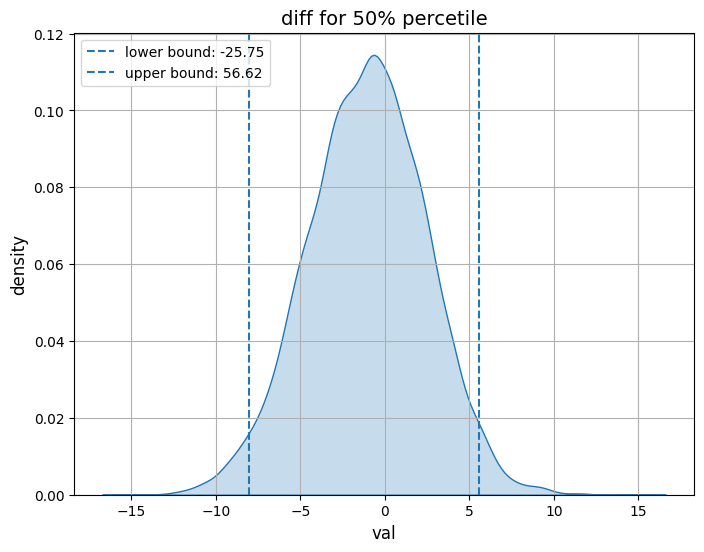

In [200]:
plt.figure(figsize=(8, 6))
sns.kdeplot(bs_diff_50, fill=True, bw_method='scott')
plt.axvline(ci_left_50, linestyle='--', 
            label=f"lower bound: {ci_95[0]:.2f}")
plt.axvline(ci_right_50, linestyle='--', 
            label=f"upper bound: {ci_95[1]:.2f}")
plt.title(f"diff for 50% percetile", fontsize=14)
plt.xlabel("val", fontsize=12)
plt.ylabel("density", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [203]:
obs_diff_mean, ci_mean, effect_flag_mean = get_mean_ci(control_revenue, test_revenue, alpha=alpha, n_bootstrap=n_bootstrap)

In [204]:
print("Все пользователи (ARPPU)")
print(f"Среднее выручки (control): {control_revenue.mean():0.2f}")
print(f"Среднее выручки (test):    {test_revenue.mean():0.2f}")
print(f"Наблюдаемая разница средних: {obs_diff_mean:0.2f}")
print(f"95% доверительный интервал разности: ({ci_mean[0]:0.2f}, {ci_mean[1]:0.2f})")
print("Статистически значимый эффект (ARPPU)?", effect_flag_mean)

Все пользователи (ARPPU)
Среднее выручки (control): 143.97
Среднее выручки (test):    144.28
Наблюдаемая разница средних: 0.31
95% доверительный интервал разности: (-8.62, 9.29)
Статистически значимый эффект (ARPPU)? False


Тут то же самое - так как интервал включает 0, мы не можем отвергнуть нулевую гипотезу о том, что изменений нет

### Задание 2 (1 балл)

В приложенном файле `sleep.csv` приведено время засыпания одного и того же человека в разные дни.

Нужно обработать эти данные и указать такое время суток (с точностью до минуты), после которого с вероятностью 0.9 этот человек уже спит.

Как можно оценить стандартное отклонение этой точечной оценки?

In [23]:
df2 = pd.read_csv("hw-3/sleep.csv")

In [24]:
df2

,Unnamed: 0,indicator,time_offset
0,2017-12-01 21:00:00,0,-60
1,2017-12-01 21:01:00,0,-59
2,2017-12-01 21:02:00,0,-58
3,2017-12-01 21:03:00,0,-57
4,2017-12-01 21:04:00,0,-56
...,...,...,...
11335,2018-02-01 23:55:00,1,115
11336,2018-02-01 23:56:00,1,116
11337,2018-02-01 23:57:00,1,117
11338,2018-02-01 23:58:00,1,118


In [25]:
df2_sorted = df2.sort_values(by='time_offset')

In [54]:
from datetime import timedelta

df2_sorted['ts'] = pd.to_datetime(df2_sorted['Unnamed: 0'])
df2_sorted['day'] = df2_sorted['ts'].dt.date
df2_sorted['clock'] = df2_sorted['ts'].dt.time


In [75]:
asleep = df2_sorted[df2_sorted['indicator'] == 1].groupby('day').min()

In [80]:
offsets = np.sort(asleep['time_offset'].values)
answer_offset = np.quantile(offsets, 0.9)
answer_offset

np.float64(46.0)

Получаем, что offset - 46

Время после которого с вероятностью 0.9 человек уже спит - 22:46:00

In [81]:
n_iter = 1000
bootstrap_estimates = []

for _ in range(n_iter):
    bootstrap_values = np.random.choice(offsets, len(offsets), True)
    bootstrap_estimates.append(np.quantile(bootstrap_values, 0.9))

std_estimate = np.std(bootstrap_estimates)
print("std for 90% quantile:", std_estimate)

std for 90% quantile: 3.1240685011695897


То есть стандратное отклонение - 3 минуты

### Задание 3. CUPED (1 балла)

Cгенерируем выборку из $1000$ сэмплов экспоненциального распределения - это будут значения нашей метрики для $1000$ пользователей

In [227]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats
from tqdm import tqdm

In [3]:
control_before = stats.expon(scale=1000).rvs(1000)

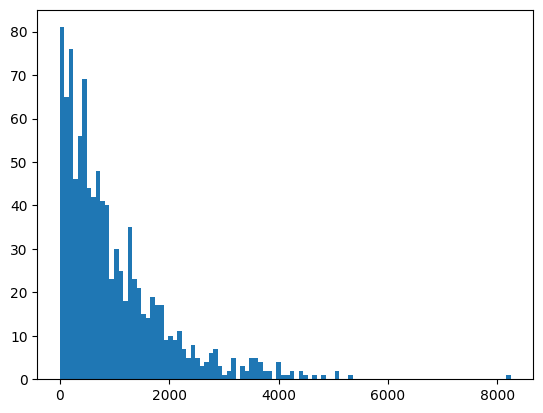

In [4]:
plt.hist(control_before, bins=100)
plt.show()

Предположим, что при наблюдении метрики в дальнейшем добавляется какой-то нормальный шум

In [5]:
control = control_before + stats.norm(loc=0, scale=100).rvs(1000)

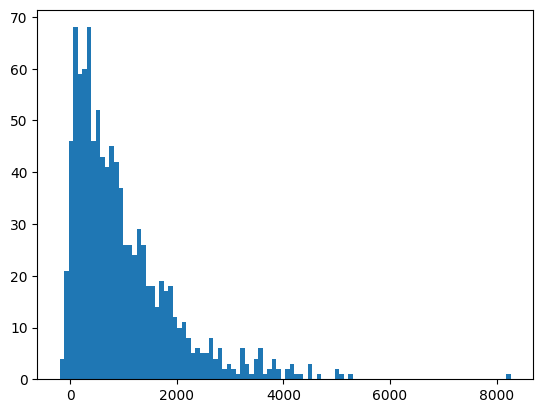

In [6]:
plt.hist(control, bins=100)
plt.show()

Теперь построим доверительный интервал для среднего значения нашей метрики и посмотрим, появилась ли стат значимая разница. Проведем такой эксперимент $10000$ раз

In [7]:
stats.norm(loc=control.mean(), scale=control.std() / np.sqrt(len(control))).ppf(
    [0.025, 0.975]
)

array([ 924.29770981, 1043.6677036 ])

In [10]:
bad_cnt = 0

N = 10000
for i in tqdm(range(N)):
    control_before = stats.expon(scale=1000).rvs(1000)
    control = control_before + stats.norm(loc=0, scale=100).rvs(1000)
    left_bound, right_bound = stats.norm(
        loc=control.mean(), scale=control.std() / np.sqrt(len(control))
    ).ppf([0.025, 0.975])

    if left_bound > 1000 or right_bound < 1000:
        bad_cnt += 1

print(f"Стат значимая разница есть в {round(bad_cnt / N, 4) * 100}% случаев;")

100%|██████████| 10000/10000 [00:07<00:00, 1355.59it/s]

Стат значимая разница есть в 5.2% случаев;


Как мы видим такой тест ошибается в около $5$% случаев, так как находит разницу в среднем. Ваша задача построить CUPED-метрику основываясь на данной метрике и провести аналогичный тест

In [ ]:
bad_cnt = 0

N = 10000
for i in tqdm(range(N)):
    control_before = stats.expon(scale=1000).rvs(1000)
    control = control_before + stats.norm(loc=0, scale=100).rvs(1000)

    mean = ...
    std = ...
    left_bound, right_bound = stats.norm(loc=mean, scale=std).ppf([0.025, 0.975])

    if left_bound > 1000 or right_bound < 1000:
        bad_cnt += 1

print(f"Стат значимая разница есть в  {round(bad_cnt / N, 4) * 100}% случаев;")

Результат должен получиться не очень хороший. Давайте теперь сделаем иначе: сгенерируем выборку из $10000$ значений, а затем выберем $2$ группы по $1000$ юзеров, которые будут нашими группами для теста. Опять добавим шум в обе группы аналогично тому, что показано в первом примере с теми же параметрами. Ваша задача вписать CUPED метрики используя знание обо всех $10000$ юзерах.

In [ ]:
bad_cnt = 0

N = 10000
for i in tqdm(range(N)):
    control_before_full = stats.expon(scale=1000).rvs(1000 * 10)
    samples_in_ab = 2000
    indexes_to_take_a = np.random.choice(
        range(samples_in_ab), samples_in_ab // 2, False
    )
    indexes_to_take_b = [x for x in range(samples_in_ab) if x not in indexes_to_take_a]

    control_before_a = control_before_full[indexes_to_take_a]
    control_before_b = control_before_full[indexes_to_take_b]

    control_after_a = control_before_a + stats.norm(loc=0, scale=100).rvs(
        samples_in_ab // 2
    )
    control_after_b = control_before_b + stats.norm(loc=0, scale=100).rvs(
        samples_in_ab // 2
    )

    control_cup_a = ...
    control_cup_b = ...

    if stats.kstest(control_cup_a, control_cup_b).pvalue < 0.05:
        bad_cnt += 1

print(f"Стат значимая разница есть в  {round(bad_cnt / N, 4) * 100}% случаев;")

Результат получился уже совсем другой. Опишите свои мысли по поводу того, из-за чего возникает такая разница:



Далее проделаем такой же эксперимент при наличии реального смещения среднего значения и посмотрим на результаты с CUPED и без.

In [ ]:
bad_cnt = 0
bad_cnt_cuped = 0

N = 10000
for i in tqdm(range(N)):
    control_before_full = sps.expon(scale=1000).rvs(1000 * 10)
    samples_in_ab = 2000
    indexes_to_take_a = np.random.choice(
        range(samples_in_ab), samples_in_ab // 2, False
    )
    indexes_to_take_b = [x for x in range(samples_in_ab) if x not in indexes_to_take_a]

    control_before_a = control_before_full[indexes_to_take_a]
    control_before_b = control_before_full[indexes_to_take_b]

    control_after_a = control_before_a + stats.norm(loc=0, scale=100).rvs(
        samples_in_ab // 2
    )
    control_after_b = control_before_b + stats.norm(loc=10, scale=100).rvs(
        samples_in_ab // 2
    )

    control_cup_a = ...
    control_cup_b = ...

    if stats.kstest(control_after_a, control_after_b).pvalue < 0.05:
        bad_cnt += 1

    if stats.kstest(control_cup_a, control_cup_b).pvalue < 0.05:
        bad_cnt_cuped += 1

print(
    f"Стат значимая разница есть в  {round(bad_cnt / N, 4) * 100}% случаев; при использовании CUPED -- в {round(bad_cnt_cuped / N, 4) * 100}% случаев"
)

### Задание 4. Методы снижения дисперсии (2 балла)

В этой части задания вам нужно применить методы снижения дисперсии с лекций, чтобы провести более точные тесты по данным из файла.

Данные представляют собой значение какой-то метрики для трех возрастных групп пользователей. Столбец group отвечает за группу, в которой находятся пользователи: 
- `None` - пользователь не участвует в АБ тесте, 
- `*_before_i` - соответствующая группа до начала теста, 
- `*_after_i` - группа после начала эксперимента

Чем больше i, тем позже было сделано наблюдение. 

Cчитайте, что юзеры всегда идут в одном порядке в группах. То есть `data[data.group == 'control_before_i']`
дает юзеров в той же последовательности, что `data[data.group == 'control_after_i']` для всех i.  Аналогичное верно для тритмента.


#### Что надо сделать:
1. Напишите тест Стьюдента самостоятельно - то есть вы должны сами вычислить тестовую статистику, а затем используя квантильную функцию определить p-value. Квантили можно брать из готовых библиотек.

2. Реализуйте пост-стратификацию и CUPED. 

3. Проведите тесты между `control_before_i` и `treatment_before_i` снчала без применения пост-стратификации и CUPED, а затем с ними. Без применения каких-либо методов такой тест покажет p-value около $0.05$ только при i == 5. Ваша задача применить методы уменьшения дисперсии, чтобы с помощью теста Стьюдента можно было обнаружить отличие на уровне значимости $0.05$

4. Опишите свои результаты.

In [206]:
data = pd.read_csv("hw-3/data_ab.csv")

In [207]:
data.head()

,age,metric,group
0,young,11309.036916,treatment_before
1,young,8496.554679,control_before
2,young,11891.862586,control_before
3,young,9229.445011,treatment_before
4,young,10410.961279,control_before


In [215]:
def post_stratified_mean(table, ratio_weights):
    """
    среднее по сегментамс весами (пост-стратификация)
    """
    result_val = 0
    for single_age in table['age'].unique():
        segment_mean = table.loc[table['age'] == single_age, 'metric'].mean()
        result_val += segment_mean * ratio_weights[single_age]
    return result_val

In [216]:
def post_stratified_variance(table, ratio_weights):
    """
    сумма дисперсий по сегментам с учётом весов (пост-стратификация)
    """
    result_val = 0
    for single_age in table['age'].unique():
        segment_var = table.loc[table['age'] == single_age, 'metric'].var()
        result_val += segment_var * ratio_weights[single_age]
    return result_val

In [222]:
def custom_ttest(group_a, group_b, approach='standard', ratio_weights=None):
    """
      - 'standard': обычный t-тест Стьюдента
      - 'strat': пост-стратификация
      - 'cuped': CUPED
    """
    test_stat = 0
    
    if approach == 'standard':
        arr_a = group_a['metric'].values
        arr_b = group_b['metric'].values
        mean_diff = np.mean(arr_a) - np.mean(arr_b)
        se = np.sqrt(np.var(arr_a, ddof=1) / len(arr_a) + 
                     np.var(arr_b, ddof=1) / len(arr_b))
        test_stat = mean_diff / se

    elif approach == 'stratified':
        mean_a = post_stratified_mean(group_a, ratio_weights)
        mean_b = post_stratified_mean(group_b, ratio_weights)
        var_a = post_stratified_variance(group_a, ratio_weights)
        var_b = post_stratified_variance(group_b, ratio_weights)
        test_stat = (mean_a - mean_b) / np.sqrt(var_a / group_a.shape[0] + 
                                                var_b / group_b.shape[0])

    elif approach == 'cuped':
        mean_a = np.mean(group_a)
        mean_b = np.mean(group_b)
        var_a = np.var(group_a, ddof=1)
        var_b = np.var(group_b, ddof=1)
        test_stat = (mean_a - mean_b) / np.sqrt(var_a / len(group_a) + 
                                                var_b / len(group_b))

    p_val = 2 * (1 - stats.norm.cdf(abs(test_stat)))
    return p_val

In [225]:
def compare_groups(df, i, approach, ratio_weights=None):
    if approach == 'standard':
        group_c = df[df['group'] == f'control_after_{i}']
        group_t = df[df['group'] == f'treatment_after_{i}']
        return custom_ttest(group_c, group_t, 'standard')

    elif approach == 'stratified':
        group_c = df[df['group'] == f'control_after_{i}']
        group_t = df[df['group'] == f'treatment_after_{i}']
        return custom_ttest(group_c, group_t, 'stratified', ratio_weights)

    elif approach == 'cuped':
        before_control = df[df['group'] == 'control_before']['metric'].values
        before_treatment = df[df['group'] == 'treatment_before']['metric'].values
        after_control = df[df['group'] == f'control_after_{i}']['metric'].values
        after_treatment = df[df['group'] == f'treatment_after_{i}']['metric'].values
        
        both_before = np.concatenate([before_control, before_treatment])
        both_after  = np.concatenate([after_control, after_treatment])

        cov_val = np.cov(both_before, both_after)[0, 1]
        var_before = np.var(both_before, ddof=1)
        
        theta = cov_val / var_before
        
        cuped_control = after_control - theta * before_control + theta * np.mean(both_before)
        cuped_treatment = after_treatment - theta * before_treatment + theta * np.mean(both_before)

        return custom_ttest(cuped_control, cuped_treatment, 'cuped')

In [226]:
total_users = data.shape[0]
weights_dict = {
    'adult': data[data['age'] == 'adult'].shape[0] / total_users,
    'young': data[data['age'] == 'young'].shape[0] / total_users,
    'old':   data[data['age'] == 'old'].shape[0] / total_users
}
results_df = pd.DataFrame()
results_df['standard'] = [compare_groups(data, i, 'standard') for i in range(1, 6)]
results_df['stratified'] = [compare_groups(data, i, 'stratified', weights_dict) for i in range(1, 6)]
results_df['cuped'] = [compare_groups(data, i, 'cuped') for i in range(1, 6)]

print("Полученные p-value:")
print(results_df)


Полученные p-value:
   standard  stratified         cuped
0  0.692238    0.318662  1.672607e-09
1  0.403327    0.041986  0.000000e+00
2  0.233634    0.004359  0.000000e+00
3  0.121458    0.000255  0.000000e+00
4  0.053784    0.000006  0.000000e+00


t‑тест выявляет отличие при i = 5

пост‑стратификация, учитывающая возраст, снижает дисперсию и выявляет отличие при i = 3

CUPED выявляет отличие при i = 1 благодаря использованию доэкспериментальных данных

### Задание 5. Линеаризация + CUPED (2.5 балла)

1. В файле `duration_aa.csv` содержатся данные для АА-теста. Проверьте гипотезу о равенстве средних длительностей визита с помощью линеаризации, постройте распределение p-value.

2. Мы поменяли верстку нашего сайта и запустили АБ-тест, чтобы выяснить, увеличилась ли средняя продолжительность визита при новом дизайне. Результаты теста лежат в файле `duration_ab.csv`. С помощью линеаризованной метрики проверьте, есть ли разница в средней длительности визита между контрольной и тестовой группами.

3. Примените CUPED и снова проведите АБ-тест. Что произошло с p-value? Почему?

В каждом пункте необходимо визуализировать распределение p-value и сонаправленность линеаризованной разности метрик и разности ratio-метрик.

In [232]:
df_aa = pd.read_csv("hw-3/duration_aa.csv")
df_aa.head()

,Unnamed: 0,user_id,group,visit_id,visit_duration
0,0,JP1F82,first,ypn3ydiml32oelnslnjv,84.0
1,1,JP1F82,first,ypy93q2g8ypdtwbpv8b5,61.0
2,2,JP1F82,first,d8m6q0bmr40wgi6zuor3,81.0
3,3,JP1F82,first,5b72re4nr84fszqx7f6e,54.0
4,4,0Y2HSZ,first,z40pmuyaczi92gmlqz6t,97.0


In [ ]:
def aggregate_user_data(df_in):
    grouped = df_in.groupby('user_id')
    total_time = grouped['visit_duration'].sum()
    n_visits = grouped['Unnamed: 0'].count()
    return total_time, n_visits

def compute_cuped_ttest(df_after, df_hist, group_a='a', group_b='b'):
    time_a, visits_a = aggregate_user_data(df_after[df_after['group'] == group_a])
    time_b, visits_b = aggregate_user_data(df_after[df_after['group'] == group_b])
    base_after = np.sum(time_a) / np.sum(visits_a)
    lin_a = time_a - base_after * visits_a
    lin_b = time_b - base_after * visits_b
    hist_a, hist_a_visits = aggregate_user_data(df_hist[df_hist['user_id'].isin(lin_a.index)])
    hist_b, hist_b_visits = aggregate_user_data(df_hist[df_hist['user_id'].isin(lin_b.index)])
    base_hist = np.sum(hist_a) / np.sum(hist_a_visits)
    lin_hist_a = hist_a - base_hist * hist_a_visits
    lin_hist_b = hist_b - base_hist * hist_b_visits
    before_all = np.concatenate([lin_hist_a, lin_hist_b])
    after_all = np.concatenate([lin_a, lin_b])
    w_coef = np.cov(before_all, after_all)[0, 1] / np.var(before_all)
    cuped_a = lin_a - w_coef * lin_hist_a + w_coef * np.mean(before_all)
    cuped_b = lin_b - w_coef * lin_hist_b + w_coef * np.mean(before_all)
    _, p_val = stats.ttest_ind(cuped_a, cuped_b)
    delta_cuped = np.mean(cuped_a) - np.mean(cuped_b)
    raw_diff = np.mean(df_after[df_after['group'] == group_a]['visit_duration'].values) - \
               np.mean(df_after[df_after['group'] == group_b]['visit_duration'].values)
    return p_val, delta_cuped, raw_diff

In [234]:
pval_aa, delta_lin_aa, raw_delta_aa = compute_linearized_ttest(df_aa, grp1='first', grp2='second')
print("AA-тест, линейризованный t-тест, p-value:", pval_aa)

AA-тест, линейризованный t-тест, p-value: 0.43727643231481905


In [229]:
def compute_linearized_ttest(df_data, grp1='first', grp2='second'):
    t1, n1 = aggregate_user_data(df_data[df_data['group'] == grp1])
    t2, n2 = aggregate_user_data(df_data[df_data['group'] == grp2])
    base_coef = np.sum(t1) / np.sum(n1)
    lin1 = t1 - base_coef * n1
    lin2 = t2 - base_coef * n2
    _, p_val = stats.ttest_ind(lin1, lin2)
    delta_lin = np.mean(lin1) - np.mean(lin2)
    raw_delta = np.mean(df_data[df_data['group'] == grp1]['visit_duration'].values) - \
                np.mean(df_data[df_data['group'] == grp2]['visit_duration'].values)
    return p_val, delta_lin, raw_delta

In [235]:
users_grp1 = df_aa[df_aa['group'] == 'first']['user_id'].unique()
users_grp2 = df_aa[df_aa['group'] == 'second']['user_id'].unique()

pvals_aa = []
lin_deltas_aa = []
raw_deltas_aa = []
for _ in tqdm(range(1000), desc="AA Bootstrap"):
    idx1 = np.random.choice(np.arange(len(users_grp1)), size=len(users_grp1), replace=True)
    idx2 = np.random.choice(np.arange(len(users_grp2)), size=len(users_grp2), replace=True)
    sample1 = users_grp1[idx1]
    sample2 = users_grp2[idx2]
    sub_df = df_aa[df_aa['user_id'].apply(lambda uid: uid in sample1 or uid in sample2)]
    p_val, d_lin, d_raw = compute_linearized_ttest(sub_df, grp1='first', grp2='second')
    pvals_aa.append(p_val)
    lin_deltas_aa.append(d_lin)
    raw_deltas_aa.append(d_raw)

AA Bootstrap: 100%|██████████| 1000/1000 [04:07<00:00,  4.04it/s]


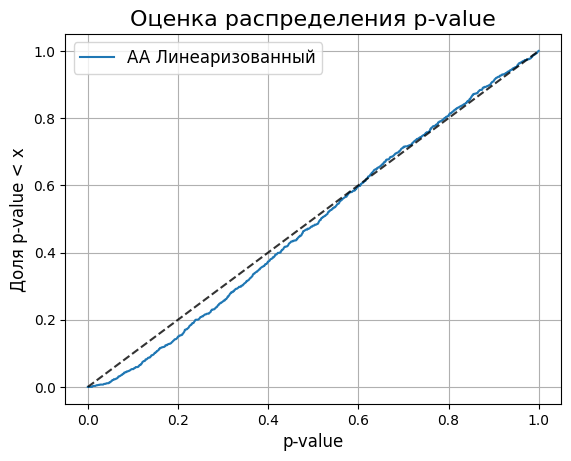

In [236]:
plot_pvalue_distribution({"AA Линеаризованный": pvals_aa})

In [239]:
def plot_delta_alignment(delta_lin, delta_raw, baseline_mean, title_text=None):
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 4))
    if title_text:
        plt.suptitle(title_text)
    
    ax_left.plot(delta_lin, label="Linearized deltas", color="blue", linestyle='-', marker='o')
    ax_left.plot(delta_raw, label="Raw deltas", color="red", linestyle='--', marker='x')
    ax_left.legend()
    
    ax_right.plot(delta_raw, label="Raw deltas", color="green", linestyle='-', marker='s')
    ax_right.plot(delta_lin / baseline_mean, label="Linearized deltas / mean(baseline)", 
                  color="purple", linestyle='--', marker='d')
    ax_right.legend()
    
    plt.show()


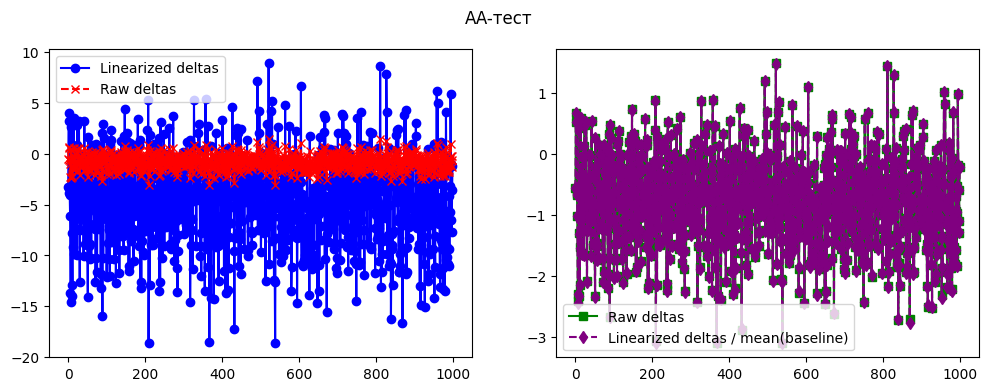

In [240]:
_, base_visits_aa = aggregate_user_data(df_aa[df_aa['group'] == 'second'])
plot_delta_alignment(lin_deltas_aa, raw_deltas_aa, np.mean(base_visits_aa), "AA-тест")

Гипотеза подтвердилась - средние похожи

In [ ]:
df_ab = pd.read_csv("hw-3/duration_ab.csv")

In [252]:
df_ab

,Unnamed: 0,user_id,group,visit_id,visit_duration
0,0,AOXLT0,a,76v7fwlgmxa73cx08zvh,125.0
1,1,AOXLT0,a,dse16a8xow680xn4ly3o,115.0
2,2,AOXLT0,a,ei17obrkatjb0uglqglr,117.0
3,3,AOXLT0,a,cp9aczsn0zd8a7u9qoel,115.0
4,4,AOXLT0,a,t421ljy1eg7qpdx3dask,123.0
...,...,...,...,...,...
11930,5960,OUFK5V,b,r71fow7gm2hhonw94w8o,124.0
11931,5961,OUFK5V,b,qkl3b7ziw9p3vhuon62n,110.0
11932,5962,OUFK5V,b,c0iv57jkc2q60bas3eoz,130.0
11933,5963,OUFK5V,b,tsz0bo4a6n3lb243kenw,92.0


In [248]:
pval_ab, delta_lin_ab, raw_delta_ab = compute_linearized_ttest(df_ab, grp1='a', grp2='b')
print("AB-тест, линейризованный t-тест, p-value:", pval_ab)

AB-тест, линейризованный t-тест, p-value: 0.05695844605154037


In [249]:
users_a = df_ab[df_ab['group'] == 'a']['user_id'].unique()
users_b = df_ab[df_ab['group'] == 'b']['user_id'].unique()

pvals_ab = []
lin_deltas_ab = []
raw_deltas_ab = []
for _ in tqdm(range(1000), desc="AB Bootstrap"):
    idx_a = np.random.choice(np.arange(len(users_a)), size=len(users_a), replace=True)
    idx_b = np.random.choice(np.arange(len(users_b)), size=len(users_b), replace=True)
    sample_a = users_a[idx_a]
    sample_b = users_b[idx_b]
    sub_df_ab = df_ab[df_ab['user_id'].apply(lambda uid: uid in sample_a or uid in sample_b)]
    p_val, d_lin, d_raw = compute_linearized_ttest(sub_df_ab, grp1='a', grp2='b')
    pvals_ab.append(p_val)
    lin_deltas_ab.append(d_lin)
    raw_deltas_ab.append(d_raw)


AB Bootstrap: 100%|██████████| 1000/1000 [04:10<00:00,  3.99it/s]


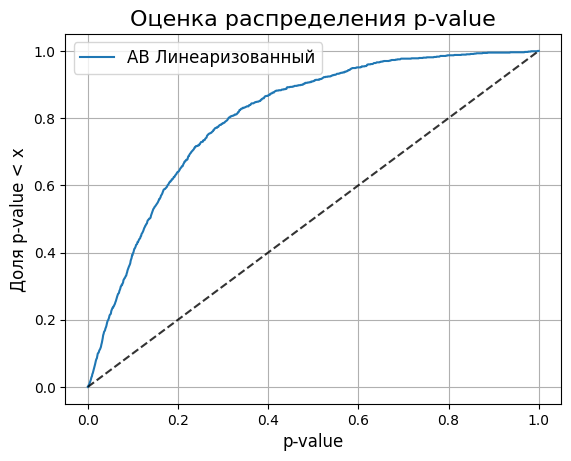

In [250]:
plot_pvalue_distribution({"AB Линеаризованный": pvals_ab})

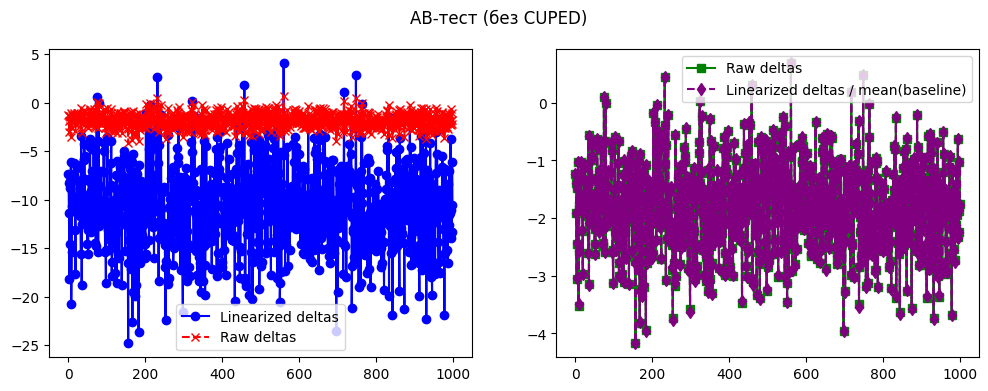

In [251]:
_, base_visits_ab = aggregate_user_data(df_ab[df_ab['group'] == 'b'])
plot_delta_alignment(lin_deltas_ab, raw_deltas_ab, np.mean(base_visits_ab), "AB-тест (без CUPED)")

Нет значимой разницы

При этом pvalue очень близко к уровню значимости


In [255]:
df_hist = pd.read_csv("hw-3/duration_hist.csv")
df_hist

,Unnamed: 0,user_id,visit_id,visit_duration
0,0,66U21N,2e9jn4qdjoot4vo9xn5g,76.0
1,1,MQE6TJ,v54g9sa6g6gcn6f7e3kk,97.0
2,2,X4A2B6,zmz8g1utfal68e1ctz8g,117.0
3,3,HFYD47,e8zvlx05icmrcn75ny5u,49.0
4,4,8C8XIX,886rt54buvgrtgah1i1f,83.0
...,...,...,...,...
11809,11809,J1LCQB,b00vmm8u43x8e5s5h6s0,94.0
11810,11810,4ENUCD,dp966q6r5qbp20l53m75,123.0
11811,11811,EAPH0N,wbxc86gjp4eo41yl5vp1,122.0
11812,11812,3SQ9LJ,lgd9v832byrvpjuufmwi,120.0


In [257]:
pval_cup, delta_cup, raw_delta_cup = compute_cuped_ttest(df_ab, df_hist, group_a='a', group_b='b')
print("AB-тест с CUPED, p-value:", pval_cup)

AB-тест с CUPED, p-value: 0.05840407033661536


In [258]:
users_a_ab = df_ab[df_ab['group'] == 'a']['user_id'].unique()
users_b_ab = df_ab[df_ab['group'] == 'b']['user_id'].unique()

pvals_cup = []
cuped_deltas = []
raw_deltas_cup = []
for _ in tqdm(range(1000), desc="CUPED Bootstrap"):
    idx_a = np.random.choice(np.arange(len(users_a_ab)), size=len(users_a_ab), replace=True)
    idx_b = np.random.choice(np.arange(len(users_b_ab)), size=len(users_b_ab), replace=True)
    sample_a = users_a_ab[idx_a]
    sample_b = users_b_ab[idx_b]
    sub_df_ab = df_ab[df_ab['user_id'].apply(lambda uid: uid in sample_a or uid in sample_b)]
    sub_df_hist = df_hist[df_hist['user_id'].apply(lambda uid: uid in sample_a or uid in sample_b)]
    p_val, d_cup, d_raw = compute_cuped_ttest(sub_df_ab, sub_df_hist, group_a='a', group_b='b')
    pvals_cup.append(p_val)
    cuped_deltas.append(d_cup)
    raw_deltas_cup.append(d_raw)

CUPED Bootstrap: 100%|██████████| 1000/1000 [07:30<00:00,  2.22it/s]


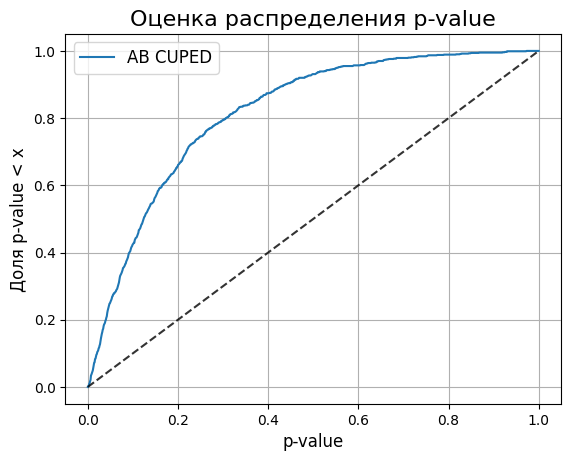

In [259]:
plot_pvalue_distribution({"AB CUPED": pvals_cup})

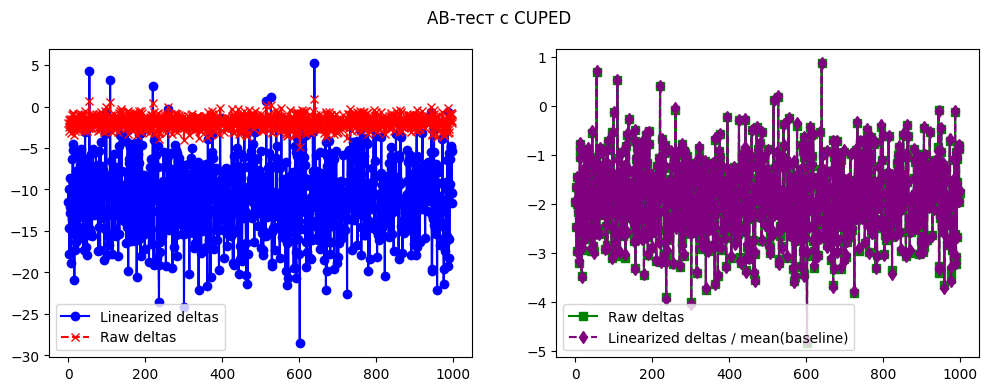

In [260]:
_, base_visits_cup = aggregate_user_data(df_ab[df_ab['group'] == 'b'])
plot_delta_alignment(cuped_deltas, raw_deltas_cup, np.mean(base_visits_cup), "AB-тест с CUPED")

p-value немного увеличился, значимой разницы все еще нет

смысла особо в CUPED я тут не вижу